In [1]:
# Load the libraries

library(vcfR)
library(ape)
library(phangorn)
library(ade4)
library(dplyr)
library(ggplot2)
library(purrr)
library(adegenet)


   *****       ***   vcfR   ***       *****
   This is vcfR 1.15.0 
     browseVignettes('vcfR') # Documentation
     citation('vcfR') # Citation
   *****       *****      *****       *****



Attaching package: ‘dplyr’


The following object is masked from ‘package:ape’:

    where


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



   /// adegenet 2.1.10 is loaded ////////////

   > overview: '?adegenet'
   > tutorials/doc/questions: 'adegenetWeb()' 
   > bug reports/feature requests: adegenetIssues()




Attaching package: ‘adegenet’


The following object is masked from ‘package:phangorn’:

    AICc




In [2]:
White_md<-read.table("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/Samplemd_files/Total_dataset_TRACwhite2011/White_1052_ctv_471inds_depthfilt_samplemd.txt", header=TRUE)
head(White_md)

,Sample,Study,Site,Country,Year,ENA,Population,QC_pass,Fws,Artemisinin,SiteCountry
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,PD0461-C,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164731,WSEA,True,0.9985067,Sensitive,MaeSot_Thailand
2,PD0462-C,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164726,WSEA,True,0.9994090,Resistant,MaeSot_Thailand
3,PD0467-C,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164725,WSEA,True,0.9993150,Sensitive,MaeSot_Thailand
4,PD0470-C,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164729,WSEA,True,0.9984425,Resistant,MaeSot_Thailand
5,PD0471-C,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164730,WSEA,True,0.9990087,Resistant,MaeSot_Thailand
6,PD0472-C,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164713,WSEA,True,0.9979894,Sensitive,MaeSot_Thailand


In [3]:
vcf<-read.vcfR("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/vcg.gz.r3/vcfs_w_newmissfilt_newpops/Depth_allelebal_hap/new_trial/Pf3D7_dep10_90x_AB0.9_qcpass_White_Allchr_combined_final_filtered_haploid.vcf.gz",verbose=T)

Scanning file to determine attributes.
File attributes:
  meta lines: 112
  header_line: 113
  variant count: 480058
  column count: 457
Meta line 112 read in.
All meta lines processed.
gt matrix initialized.
Character matrix gt created.
  Character matrix gt rows: 480058
  Character matrix gt cols: 457
  skip: 0
  nrows: 480058
  row_num: 0
Processed variant: 480058
All variants processed


In [ ]:
genind <- vcfR2genind(vcf)

In [31]:
genclone <- poppr::as.genclone(genind_vcf)

In [49]:
saveRDS(genclone,"/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/white2011_genclone.rds")

In [3]:
White_md<-read.table("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/Samplemd_files/Total_dataset_TRACwhite2011/White_1052_ctv_471inds_depthfilt_samplemd.txt", header=TRUE)

In [33]:

ploidy(genclone) <- 1

###### set.seed(100)


In [34]:
set.seed(100)
clus_white<-find.clusters(genclone, n.pca = 200, 
                          choose.n.clust=FALSE,
                          method = "ward", 
                          stat = "BIC", 
                          criterion = "diffNgroup")

In [5]:
 saveRDS(clus_white,"/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/clus_white2011.rds")

ERROR: Error: object 'clus_white' not found


In [5]:
clus_white<-readRDS("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/clus_white2011.rds")

In [6]:
n_levels<-nlevels(clus_white$grp)
n_levels

[1] 8

With sampling location prior

In [7]:
genclone<-readRDS("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/white2011_genclone.rds")

In [8]:
dapc_wprior<- dapc(genclone, pop=White_md$SiteCountry, n.pca = n_levels-1, n.da=5)

Loading required package: poppr



Registered S3 method overwritten by 'pegas':
  method      from
  print.amova ade4

This is poppr version 2.9.6. To get started, type package?poppr
OMP parallel support: available


Attaching package: ‘poppr’


The following object is masked from ‘package:phangorn’:

    upgma




In [10]:
saveRDS(dapc_wprior,"/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/dapc_wprior.rds")

In [12]:
set.seed(10)
cols <- rainbow(length(unique(White_md$SiteCountry)))
# Create a named vector to map SiteCountry to colors
site_colors <- setNames(cols, unique(White_md$SiteCountry))

In [24]:
# Figure 2: Scatter plot (x-axis = 1, y-axis = 2) for White_md$SiteCountry
pdf("Figure2_with prior.pdf", width = 8, height = 6)  # Open PDF device
scatter(dapc_wprior, xax=1, yax=2,
        grp = White_md$SiteCountry <- factor(White_md$SiteCountry, levels = c(
          "MaeSot_Thailand", "Sisakhet_Thailand", "Ranong_Thailand",
          "Ratanakiri_Cambodia", "PreahVihear_Cambodia", "Pursat_Cambodia",
          "Pailin_Cambodia", "BinhPhuoc_VietNam")),
        col = site_colors,  # Use the rainbow colors
        cstar = 0,
        clab=0,
        legend = T,
        #cleg=1.5,
        posi.leg="topright",
        scree.da=T,
        scree.pca=T)
dev.off()

pdf 
  2

With K means clustering

In [15]:
dapc1<-readRDS("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/dapc_white2011.rds")

In [5]:
dapc1

	#################################################
	# Discriminant Analysis of Principal Components #
	#################################################
class: dapc
$call: dapc.genind(x = genclone, pop = clus_white$grp, n.pca = n_levels - 
    1, n.da = 5)

$n.pca: 7 first PCs of PCA used
$n.da: 5 discriminant functions saved
$var (proportion of conserved variance): 0.26

$eig (eigenvalues): 2291 894.7 726.7 687.2 466.8 ...

  vector    length content                   
1 $eig      7      eigenvalues               
2 $grp      448    prior group assignment    
3 $prior    8      prior group probabilities 
4 $assign   448    posterior group assignment
5 $pca.cent 510135 centring vector of PCA    
6 $pca.norm 510135 scaling vector of PCA     
7 $pca.eig  446    eigenvalues of PCA        

  data.frame    nrow   ncol content                                          
1 $tab          448    7    retained PCs of PCA                              
2 $means        8      7    group means       

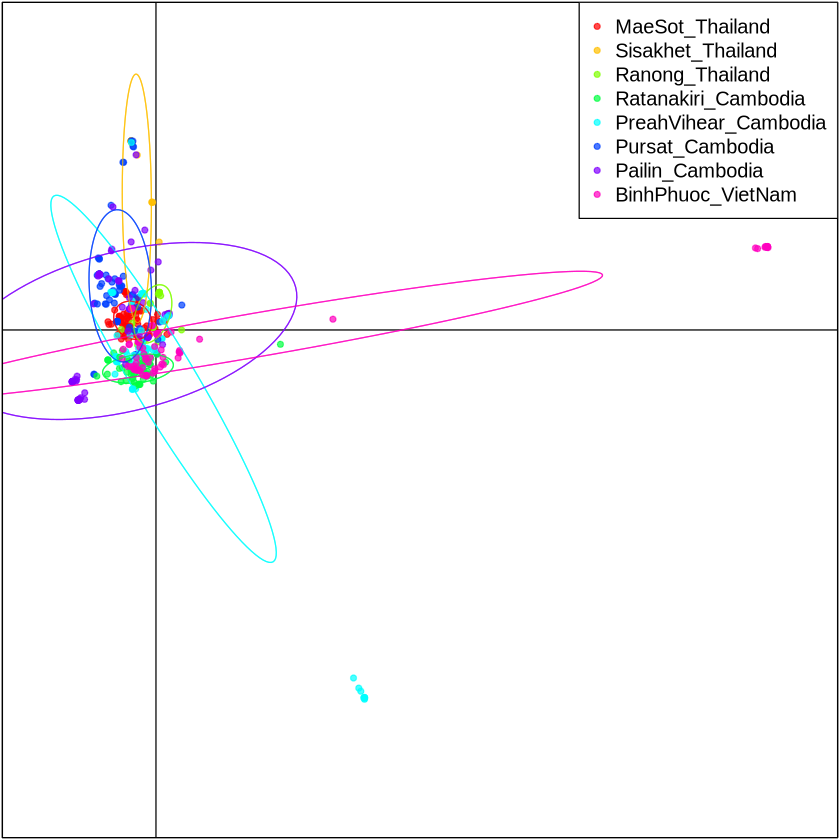

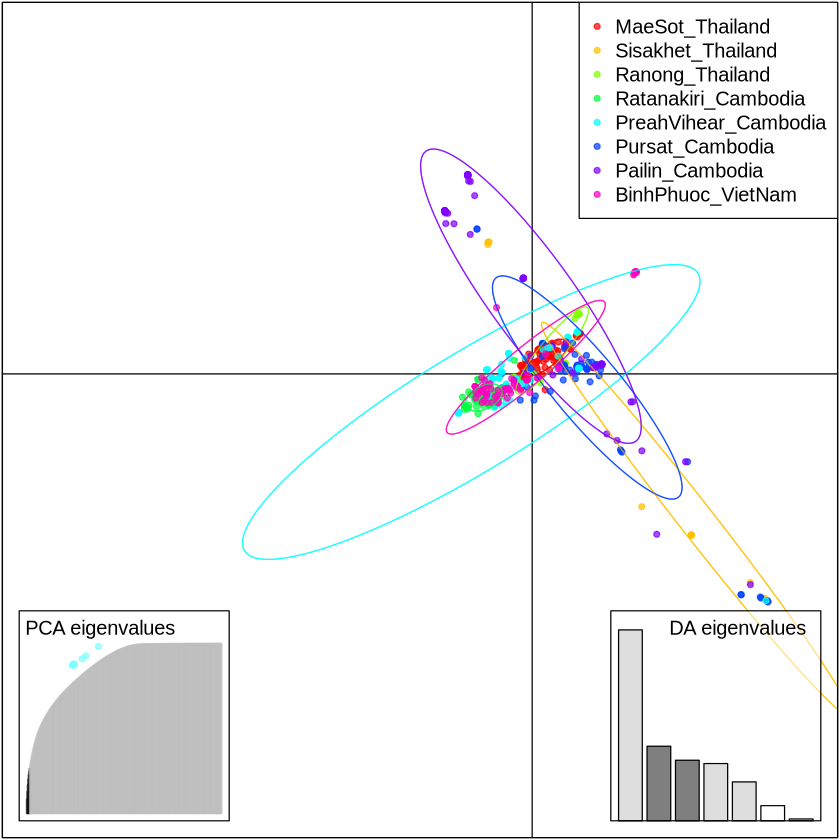

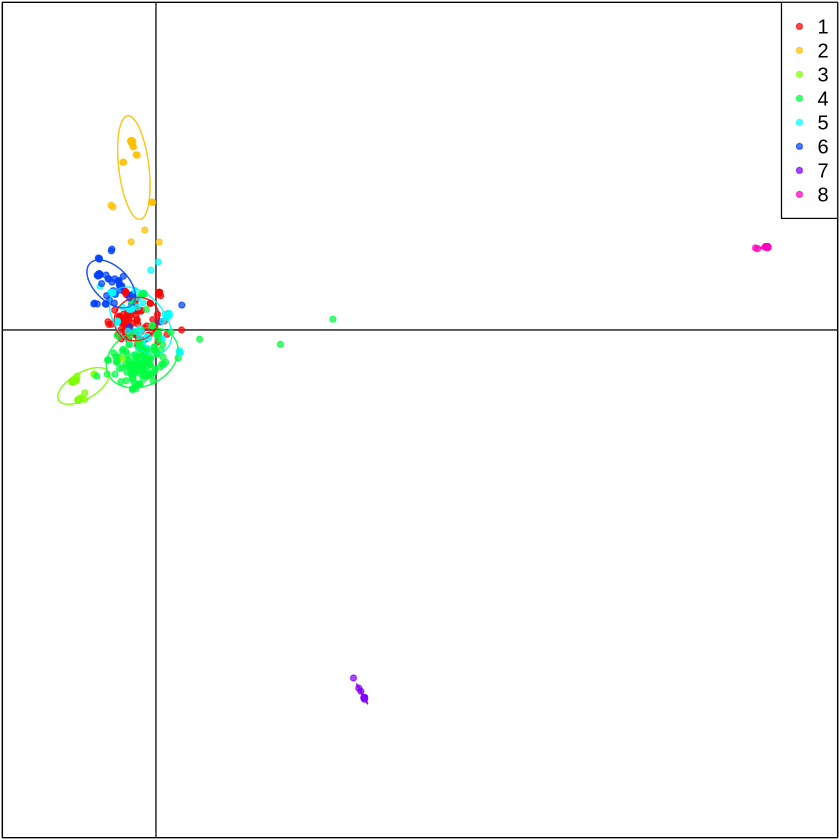

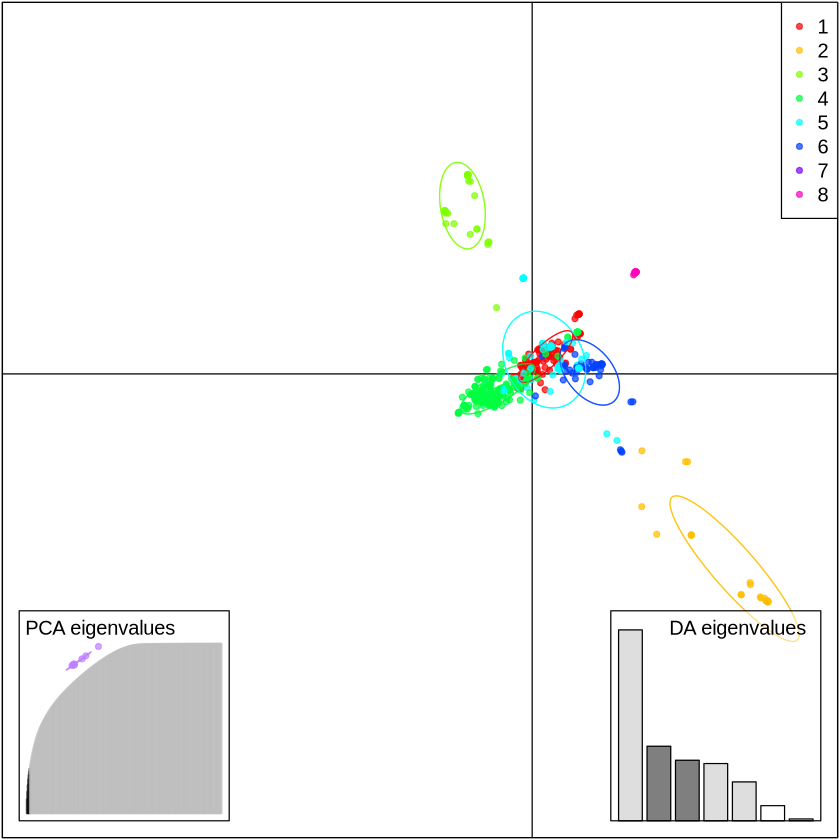

In [11]:
scatter(dapc1,  xax=1, yax=2,
        grp = White_md$SiteCountry <- factor(White_md$SiteCountry, levels = c(
          "MaeSot_Thailand", "Sisakhet_Thailand", "Ranong_Thailand",
          "Ratanakiri_Cambodia", "PreahVihear_Cambodia", "Pursat_Cambodia",
          "Pailin_Cambodia", "BinhPhuoc_VietNam")),
        col = site_colors,  # Use the rainbow colors
        cstar = 0,
        clab=0,
        legend = T,
        #cleg=1.5,
        posi.leg="topright",
        scree.da=FALSE,
        scree.pca=FALSE)
scatter(dapc1, xax=2, yax=3,
        grp = White_md$SiteCountry <- factor(White_md$SiteCountry, levels = c(
          "MaeSot_Thailand", "Sisakhet_Thailand", "Ranong_Thailand",
          "Ratanakiri_Cambodia", "PreahVihear_Cambodia", "Pursat_Cambodia",
          "Pailin_Cambodia", "BinhPhuoc_VietNam")),
        col = site_colors,  # Use the rainbow colors
        cstar = 0,
        clab=0,
        legend = T,
        #cleg=1.5,
        posi.leg="topright",
        scree.da=T,
        scree.pca=T)

scatter(dapc1, xax=1, yax=2, 
        grp = clus_white$grp,
        col = site_colors,  # Use the rainbow colors
        cstar = 0,
        clab=0,
        legend = T,
        #cleg=1.5,
        posi.leg="topright",
        scree.da=FALSE,
        scree.pca=FALSE)

scatter(dapc1, xax=2, yax=3, 
        grp = clus_white$grp,
        col = site_colors,  # Use the rainbow colors
        cstar = 0,
        clab=0,
        legend = T,
        #cleg=1.5,
        posi.leg="topright",
        scree.da=T,
        scree.pca=T)

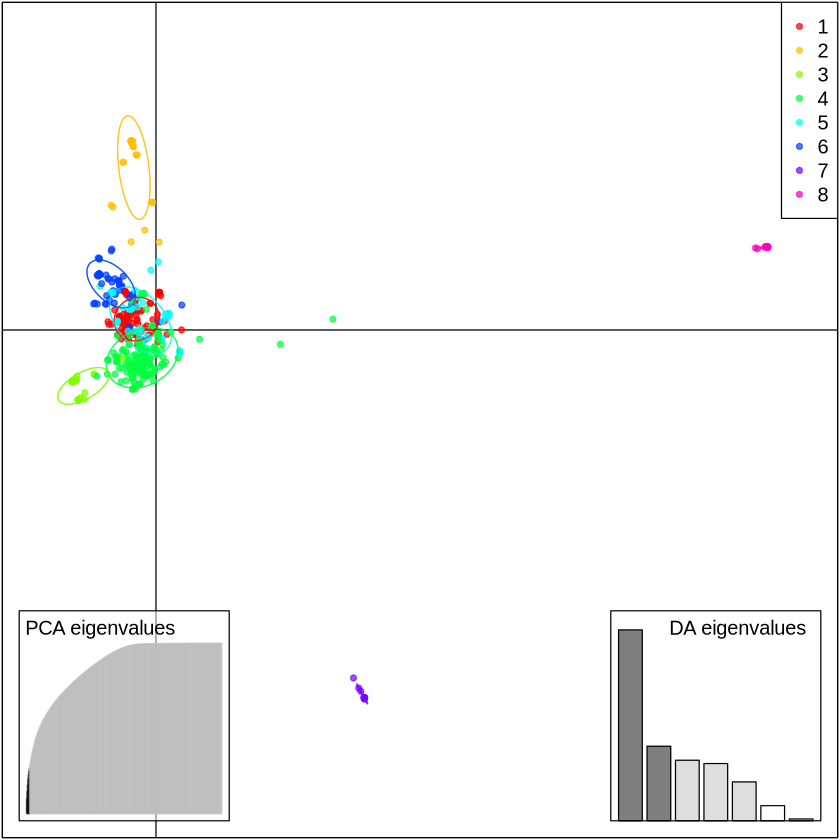

In [17]:
scatter(dapc1, xax=1, yax=2, 
        grp = clus_white$grp,
        col = site_colors,  # Use the rainbow colors
        cstar = 0,
        clab=0,
        legend = T,
        #cleg=1.5,
        posi.leg="topright",
        scree.da=T,
        scree.pca=T)

In [18]:
# Figure 2: Scatter plot (x-axis = 1, y-axis = 2) for White_md$SiteCountry
pdf("Figure2_bycluster_x1_y1.pdf", width = 8, height = 6)  # Open PDF device
scatter(dapc1, xax=1, yax=2, 
        grp = clus_white$grp,
        col = site_colors,  # Use the rainbow colors
        cstar = 0,
        clab=0,
        legend = T,
        #cleg=1.5,
        posi.leg="topright",
        scree.da=T,
        scree.pca=T)
dev.off()  # Close the PDF device

pdf 
  2

In [15]:

# Figure 4: Scatter plot (x-axis = 2, y-axis = 3) for White_md$SiteCountry
pdf("Figure4_Scatter_SiteCountry_x2_y3.pdf", width = 8, height = 6)  # Open PDF device
scatter(dapc1, xax = 2, yax = 3,
        grp = White_md$SiteCountry <- factor(White_md$SiteCountry, levels = c(
          "MaeSot_Thailand", "Sisakhet_Thailand", "Ranong_Thailand",
          "Ratanakiri_Cambodia", "PreahVihear_Cambodia", "Pursat_Cambodia",
          "Pailin_Cambodia", "BinhPhuoc_VietNam")),
        col = site_colors,  # Use the rainbow colors
        cstar = 0,
        clab = 0,
        legend = T,
        posi.leg = "topright",
        scree.da = TRUE,
        scree.pca = TRUE)
dev.off()  # Close the PDF device


pdf 
  2

In [20]:
 #Extract individual coordinates from the DAPC object
dapc_result<-dapc1
str(groups)
# 1. Extract individual coordinates
ind_coords <- dapc_result$ind.coord

# 2. Get group assignments
groups <- dapc_result$assign
#groups
# 3. Calculate group centers
group_centers <- dapc_result$grp.coord

# 4. Calculate distances from group centers
distances <- numeric(nrow(ind_coords))
for(i in 1:nrow(ind_coords)) {
  group <- as.numeric(groups[i])
  center <- group_centers[rownames(group_centers) == group, ]
  distances[i] <- sqrt(sum((ind_coords[i,] - center)^2))
}

SiteCountry<-White_md[,"SiteCountry"]
ind_coords<-cbind(ind_coords,distances,assgn_clus=groups,Initial_SiteCountry=as.character(SiteCountry))
head(ind_coords)

# 5. Determine a threshold (e.g., 1.5 times the average distance)
threshold <- 1.5 * mean(distances)

# 6. Select individuals within the threshold
selected_individuals <- which(distances <= threshold)

# 7. Create a new dataset with only the selected individuals
selected_data <-ind_coords[selected_individuals,]
selected_data <- as.data.frame(selected_data) %>%
  filter(assgn_clus %in% c(1, 4, 6))
print(paste0("Number of Individuals:",length(selected_data[,1])))

head(selected_data)
table(selected_data$assgn_clus)

function (x)  


,LD1,LD2,LD3,LD4,LD5,distances,assgn_clus,Initial_SiteCountry
PD0461-C,-1.01699856260639,-0.169347936719748,0.212367660535908,2.49867038994486,0.375615846278129,0.948235673044559,1,MaeSot_Thailand
PD0462-C,-1.96037011692572,-0.225884495508524,0.0496630440311765,2.16498277344871,1.00828173278814,1.61205865466336,1,MaeSot_Thailand
PD0467-C,-0.16202691001055,0.539272292054851,-0.659248279810657,2.42125538645531,0.170187835824631,1.69188308483142,1,MaeSot_Thailand
PD0470-C,-1.29574223193977,0.777004386546247,0.998254653527631,2.66660288390732,0.693822705280288,0.49572311651445,1,MaeSot_Thailand
PD0471-C,-0.0493145595619541,0.0787367090860715,0.188860553384642,2.33123595359583,0.556844224134261,1.27203686223828,1,MaeSot_Thailand
PD0472-C,-0.4731920356229,0.213336660944541,0.16271273516606,2.63909050720115,0.394511082349754,0.866207254706179,1,MaeSot_Thailand


[1] "Number of Individuals:270"


,LD1,LD2,LD3,LD4,LD5,distances,assgn_clus,Initial_SiteCountry
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
PD0461-C,-1.01699856260639,-0.169347936719748,0.212367660535908,2.49867038994486,0.375615846278129,0.948235673044559,1,MaeSot_Thailand
PD0462-C,-1.96037011692572,-0.225884495508524,0.0496630440311765,2.16498277344871,1.00828173278814,1.61205865466336,1,MaeSot_Thailand
PD0467-C,-0.16202691001055,0.539272292054851,-0.659248279810657,2.42125538645531,0.170187835824631,1.69188308483142,1,MaeSot_Thailand
PD0470-C,-1.29574223193977,0.777004386546247,0.998254653527631,2.66660288390732,0.693822705280288,0.49572311651445,1,MaeSot_Thailand
PD0471-C,-0.0493145595619541,0.0787367090860715,0.188860553384642,2.33123595359583,0.556844224134261,1.27203686223828,1,MaeSot_Thailand
PD0472-C,-0.4731920356229,0.213336660944541,0.16271273516606,2.63909050720115,0.394511082349754,0.866207254706179,1,MaeSot_Thailand



  1   4   6 
 89 156  25 

[1] "Number of Individuals:270"


,LD1,LD2,LD3,LD4,LD5,distances,assgn_clus,Initial_SiteCountry
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
PD0461-C,-1.01699856260639,-0.169347936719748,0.212367660535908,2.49867038994486,0.375615846278129,0.948235673044559,1,MaeSot_Thailand
PD0462-C,-1.96037011692572,-0.225884495508524,0.0496630440311765,2.16498277344871,1.00828173278814,1.61205865466336,1,MaeSot_Thailand
PD0467-C,-0.16202691001055,0.539272292054851,-0.659248279810657,2.42125538645531,0.170187835824631,1.69188308483142,1,MaeSot_Thailand
PD0470-C,-1.29574223193977,0.777004386546247,0.998254653527631,2.66660288390732,0.693822705280288,0.49572311651445,1,MaeSot_Thailand
PD0471-C,-0.0493145595619541,0.0787367090860715,0.188860553384642,2.33123595359583,0.556844224134261,1.27203686223828,1,MaeSot_Thailand
PD0472-C,-0.4731920356229,0.213336660944541,0.16271273516606,2.63909050720115,0.394511082349754,0.866207254706179,1,MaeSot_Thailand



  1   4   6 
 89 156  25 

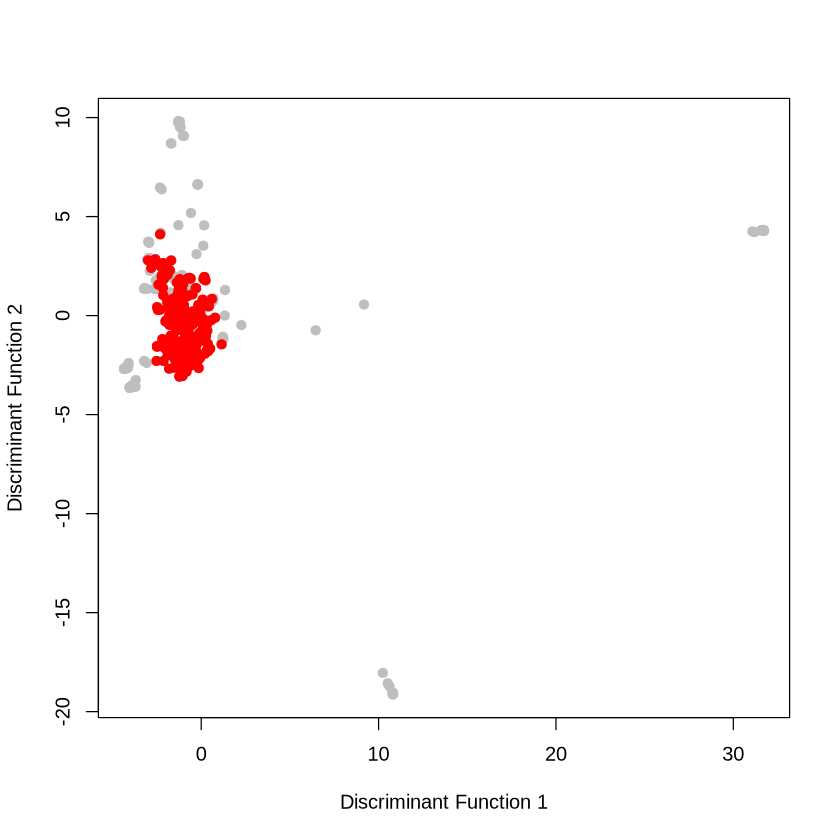

In [12]:
par(bg="white")
plot(dapc_result$ind.coord, col = "grey", pch = 19, xlab = "Discriminant Function 1", ylab = "Discriminant Function 2")
points(selected_data$LD1, selected_data$LD2,col = "red", pch = 19)

In [21]:

# Create a dataframe with the selected data points and their nearest group labels
selected_df <- as.data.frame(selected_data) %>% 
  tibble::rownames_to_column(var = "Individual") %>%
  rowwise() 

head(selected_df)

selected_df <- as.data.frame(selected_data) %>% 
  tibble::rownames_to_column(var = "Individual") %>%
  left_join(White_md, by = c("Individual" = "Sample"))
head(selected_df)

Individual,LD1,LD2,LD3,LD4,LD5,distances,assgn_clus,Initial_SiteCountry
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
PD0461-C,-1.01699856260639,-0.169347936719748,0.212367660535908,2.49867038994486,0.375615846278129,0.948235673044559,1,MaeSot_Thailand
PD0462-C,-1.96037011692572,-0.225884495508524,0.0496630440311765,2.16498277344871,1.00828173278814,1.61205865466336,1,MaeSot_Thailand
PD0467-C,-0.16202691001055,0.539272292054851,-0.659248279810657,2.42125538645531,0.170187835824631,1.69188308483142,1,MaeSot_Thailand
PD0470-C,-1.29574223193977,0.777004386546247,0.998254653527631,2.66660288390732,0.693822705280288,0.49572311651445,1,MaeSot_Thailand
PD0471-C,-0.0493145595619541,0.0787367090860715,0.188860553384642,2.33123595359583,0.556844224134261,1.27203686223828,1,MaeSot_Thailand
PD0472-C,-0.4731920356229,0.213336660944541,0.16271273516606,2.63909050720115,0.394511082349754,0.866207254706179,1,MaeSot_Thailand


,Individual,LD1,LD2,LD3,LD4,LD5,distances,assgn_clus,Initial_SiteCountry,Study,Site,Country,Year,ENA,Population,QC_pass,Fws,Artemisinin,SiteCountry
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<fct>
1,PD0461-C,-1.01699856260639,-0.169347936719748,0.212367660535908,2.49867038994486,0.375615846278129,0.948235673044559,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164731,WSEA,True,0.9985067,Sensitive,MaeSot_Thailand
2,PD0462-C,-1.96037011692572,-0.225884495508524,0.0496630440311765,2.16498277344871,1.00828173278814,1.61205865466336,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164726,WSEA,True,0.9994090,Resistant,MaeSot_Thailand
3,PD0467-C,-0.16202691001055,0.539272292054851,-0.659248279810657,2.42125538645531,0.170187835824631,1.69188308483142,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164725,WSEA,True,0.9993150,Sensitive,MaeSot_Thailand
4,PD0470-C,-1.29574223193977,0.777004386546247,0.998254653527631,2.66660288390732,0.693822705280288,0.49572311651445,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164729,WSEA,True,0.9984425,Resistant,MaeSot_Thailand
5,PD0471-C,-0.0493145595619541,0.0787367090860715,0.188860553384642,2.33123595359583,0.556844224134261,1.27203686223828,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164730,WSEA,True,0.9990087,Resistant,MaeSot_Thailand
6,PD0472-C,-0.4731920356229,0.213336660944541,0.16271273516606,2.63909050720115,0.394511082349754,0.866207254706179,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164713,WSEA,True,0.9979894,Sensitive,MaeSot_Thailand


In [23]:
selected_df$LD1 <- as.numeric(selected_df$LD1)
selected_df$LD2 <- as.numeric(selected_df$LD2)

# Figure 4: Scatter plot (x-axis = 2, y-axis = 3) for White_md$SiteCountry
pdf("Selected_inds.pdf", width = 8, height = 6)  # Open PDF
ggplot(selected_df, aes(x = LD1, y = LD2, color = assgn_clus)) +
  geom_point() +
  labs(
    x = "Discriminant Function 1", 
    y = "Discriminant Function 2", 
    color = "Cluster number"  # Set the legend title
  ) +
  theme_minimal() +
  xlim(-10, 10) +
  ylim(-10, 10)  # Optional: adds clean background style and axis limits
dev.off()

pdf 
  2

In [15]:

bycluster<- selected_df %>% .[,c(-2,-3,-4,-5,-6)]
head(bycluster)


,Individual,distances,assgn_clus,Initial_SiteCountry,Study,Site,Country,Year,ENA,Population,QC_pass,Fws,Artemisinin,SiteCountry
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<fct>
1,PD0461-C,0.948235673044559,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164731,WSEA,True,0.9985067,Sensitive,MaeSot_Thailand
2,PD0462-C,1.61205865466336,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164726,WSEA,True,0.9994090,Resistant,MaeSot_Thailand
3,PD0467-C,1.69188308483142,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164725,WSEA,True,0.9993150,Sensitive,MaeSot_Thailand
4,PD0470-C,0.49572311651445,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164729,WSEA,True,0.9984425,Resistant,MaeSot_Thailand
5,PD0471-C,1.27203686223828,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164730,WSEA,True,0.9990087,Resistant,MaeSot_Thailand
6,PD0472-C,0.866207254706179,1,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164713,WSEA,True,0.9979894,Sensitive,MaeSot_Thailand


In [16]:
bycluster %>% filter(,assgn_clus==4) %>% dplyr::select(SiteCountry) %>% table()


SiteCountry
     MaeSot_Thailand    Sisakhet_Thailand      Ranong_Thailand 
                   9                    0                    3 
 Ratanakiri_Cambodia PreahVihear_Cambodia      Pursat_Cambodia 
                  54                   35                    5 
     Pailin_Cambodia    BinhPhuoc_VietNam 
                   2                   48 

In [24]:
setwd("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/Samplemd_files/Newest_bydapcclusters_remoutliers")

write.table(bycluster, file="Allchr_Whitefullfilt_Newdapc_bycluster_md.txt", quote=FALSE, sep="\t", row.names=FALSE)
write.table(bycluster$Individual, file="Allchr_Whitefullfilt_Newdapc_bycluster_ids.txt", quote=FALSE, sep="\t", row.names=FALSE)


In [2]:
md<-read.table("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/Samplemd_files/Newest_bydapcclusters_remoutliers/Allchr_Whitefullfilt_Newdapc_bycluster_md.txt", header=T)


In [16]:
setwd("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/Samplemd_files/samples_doublecol_forplink")

maesot_ids <- md[md$assgn_clus == 1, "Individual"]
# Create a 2-column matrix with values repeated
maesot_ids_plink <- cbind(maesot_ids, maesot_ids)
# Write the matrix to a .txt file without quotes
write.table(maesot_ids_plink, "maesot_ids_clus1_plink.txt", 
            row.names = FALSE, col.names = FALSE, quote = FALSE)


binhrata_ids <- md[md$assgn_clus == 4, "Individual"]
# Create a 2-column matrix with values repeated
binhrata_ids_plink <- cbind(binhrata_ids, binhrata_ids)
# Write the matrix to a .txt file without quotes
write.table(binhrata_ids_plink, "binhrata_ids_clus4_plink.txt", 
            row.names = FALSE, col.names = FALSE, quote = FALSE)

puspai_ids <- md[md$assgn_clus == 6, "Individual"]
# Create a 2-column matrix with values repeated
puspai_ids_plink <- cbind(puspai_ids, puspai_ids)
# Write the matrix to a .txt file without quotes
write.table(puspai_ids_plink, "puspai_clus6_plink.txt", 
            row.names = FALSE, col.names = FALSE, quote = FALSE)


In [18]:
Top35 <- bycluster %>%
  group_by(assgn_clus) %>%               # Group by SiteCountry
  arrange(distances) %>%                   # Arrange by distances in ascending order within each group
  slice_head(n = 35)  
# Save each Assgn_grp subset as a separate text file
Top35 %>%
  group_split(assgn_clus) %>%                        # Split by Assgn_grp
  walk(~ write.table(.x, 
                     file = paste0(unique(.x$assgn_clus), "_Top30.txt"), 
                     sep = "\t", 
                     row.names = FALSE, 
                     quote = FALSE))
pop<-c("Maesot","BinhPhuoc_Rata","PusPai")
Top35 %>%
  group_split(assgn_clus) %>%                        # Split by Assgn_grp
  walk(~ write.table(.x[,1], 
                     file = paste0(unique(.x$assgn_clus), "_Top30_ids.txt"), 
                     sep = "\t", 
                     row.names = FALSE, 
                     quote = FALSE))

Warning message:
“... is ignored in group_split(<grouped_df>), please use group_by(..., .add =
TRUE) %>% group_split()”


Warning message:
“... is ignored in group_split(<grouped_df>), please use group_by(..., .add =
TRUE) %>% group_split()”


In [30]:
unique(pop)

[1] "Maesot"         "BinhPhuoc_Rata" "PusPai"